In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

from gamma.cutcount import (
    CeAcCutCountConfig,
    EnergyWindowSpec,
    estimate_ceac_mixture_cutcount,
)
from gamma.efficiency import EfficiencyFitSpec, fit_efficiency_model
from gamma.artifacts import ArtifactStore


In [2]:
store = ArtifactStore(repo_root / "artifacts")

# Build Config

In [3]:
cfg = CeAcCutCountConfig(
    ce_window=EnergyWindowSpec(center_keV=1022.0, resolution_pct_fwhm=8.0, nsigma=2.0),
    ac_window=EnergyWindowSpec(center_keV=440.0,  resolution_pct_fwhm=8.0, nsigma=2.0),  # or 218.0
)

# Load Calibrated Experiments

In [4]:
exp_mix = "ANIL_MIX_SD__agg__bkgsub"
exp_ce  = "ANIL_CE_SD__agg__bkgsub"
exp_ac  = "ANIL_AC_SD__agg__bkgsub"
cal_tag = "peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1"

mix_cal = store.load_calibration(exp_mix, cal_tag)
ce_cal  = store.load_calibration(exp_ce,  cal_tag)
ac_cal  = store.load_calibration(exp_ac,  cal_tag)

# Example: Load Templates

In [5]:
mix_label = mix_cal.labels[0]
ce_template_label = ce_cal.labels[0]

print(f"Mix label: {mix_label}")
print(f"Ce template label: {ce_template_label}")

mix_spec = mix_cal.calibrated[mix_label]
ce_tpl   = ce_cal.calibrated[ce_template_label]

Mix label: 1.953:3.906
Ce template label: 1.95312


### Visualize Choice:

C:\Users\pomar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


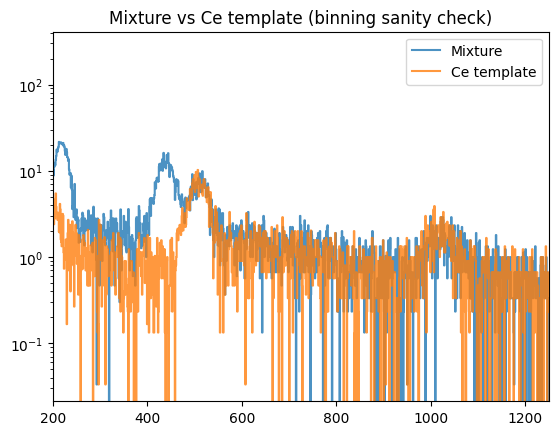

In [6]:
x_keV = np.asarray(mix_spec["bin_centers_kev"], dtype=float)
y_mix = np.asarray(mix_spec["counts_vals"], dtype=float)
y_ce_template = np.asarray(ce_tpl["counts_vals"], dtype=float)

# quick sanity plot: same binning?
plt.figure()
plt.step(x_keV, y_mix, where="mid", label="Mixture", alpha=0.8)
plt.step(x_keV, y_ce_template, where="mid", label="Ce template", alpha=0.8)
plt.yscale("log")
plt.xlim(200, 1250)
plt.legend()
plt.title("Mixture vs Ce template (binning sanity check)")
plt.show()

# Build Label $\rightarrow$ Activity Truth maps

In [7]:
truth_ce = store.load_ground_truth(exp_ce)["labels"]
truth_ac = store.load_ground_truth(exp_ac)["labels"]

# label -> activity_Bq
ce_truth_bq = {
    lbl: float(truth_ce[lbl]["ce134"]["value"])
    for lbl in truth_ce
    if ("ce134" in truth_ce[lbl]) and (truth_ce[lbl]["ce134"].get("value") is not None)
}

ac_truth_bq = {
    lbl: float(truth_ac[lbl]["ac225"]["value"])
    for lbl in truth_ac
    if ("ac225" in truth_ac[lbl]) and (truth_ac[lbl]["ac225"].get("value") is not None)
}

print("Ce truth entries:", len(ce_truth_bq))
print("Ac truth entries:", len(ac_truth_bq))

Ce truth entries: 10
Ac truth entries: 10


# Initialize and Fit Efficiency Models 

In [15]:
ce_emin, ce_emax = cfg.ce_window.bounds()
ac_emin, ac_emax = cfg.ac_window.bounds()

ce_fit = EfficiencyFitSpec(
    name="ce134_win1022_counts60s_v2",
    label_to_activity=ce_truth_bq,
    model_type="nonparalyzable",          # or "nonparalyzable"
    emin_keV=float(ce_emin),
    emax_keV=float(ce_emax),
    livetime_s=60.0,
    rate_units="counts",
)

ac_fit = EfficiencyFitSpec(
    name="ac225_win_counts60s_v2",  # rename if you want "win218" vs "win440"
    label_to_activity=ac_truth_bq,
    model_type="nonparalyzable",            # or "nonparalyzable"
    emin_keV=float(ac_emin),
    emax_keV=float(ac_emax),
    livetime_s=60.0,
    rate_units="counts",
)

ce_eff_model = fit_efficiency_model(ce_cal, ce_fit)
ac_eff_model = fit_efficiency_model(ac_cal, ac_fit)

print("Ce model:", ce_eff_model.name, ce_eff_model.model_type, ce_eff_model.params)
print("Ac model:", ac_eff_model.name, ac_eff_model.model_type, ac_eff_model.params)


Ce model: ce134_win1022_counts60s_v2 nonparalyzable {'a': 2.1722779095662186, 'b': 3.480697170073751e-06}
Ac model: ac225_win_counts60s_v2 nonparalyzable {'a': 3.4677227169834506, 'b': 6.991402446751088e-08}


### Visualize Fit Relation

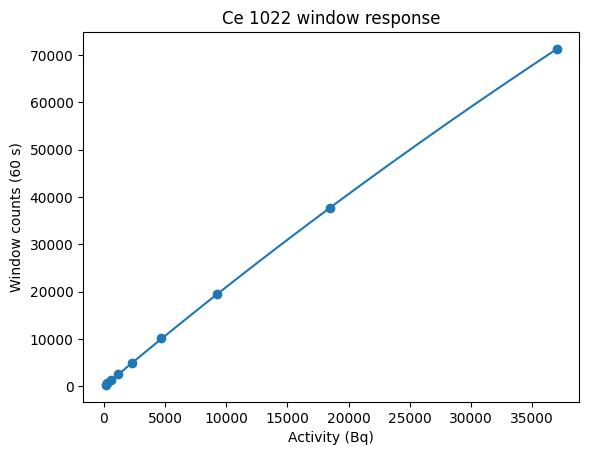

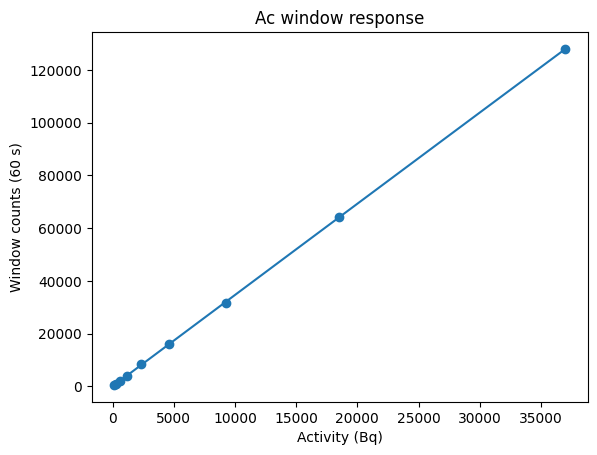

In [16]:
def plot_eff_model_points(model, title):
    A = np.array(model.meta["A_used"], dtype=float)
    R = np.array(model.meta["R_used"], dtype=float)
    a = float(model.params["a"])
    b = float(model.params["b"])

    xs = np.linspace(A.min(), A.max(), 200)
    if model.model_type == "linear":
        ys = a*xs + b
    else:
        ys = (a*xs) / (1 + b*xs)

    plt.figure()
    plt.scatter(A, R)
    plt.plot(xs, ys)
    plt.xlabel("Activity (Bq)")
    plt.ylabel("Window counts (60 s)")
    plt.title(title)
    plt.show()

plot_eff_model_points(ce_eff_model, "Ce 1022 window response")
plot_eff_model_points(ac_eff_model, "Ac window response")


# Run CutCount

Estimated activities (Bq): {'ce134': 83.76139709861329, 'ac225': 149.34628740861356}
Estimated uncertainties (Bq): {'ce134': 6.2123249192277585, 'ac225': 6.562689177411924}
Scale Ce template: 0.9867992766726946


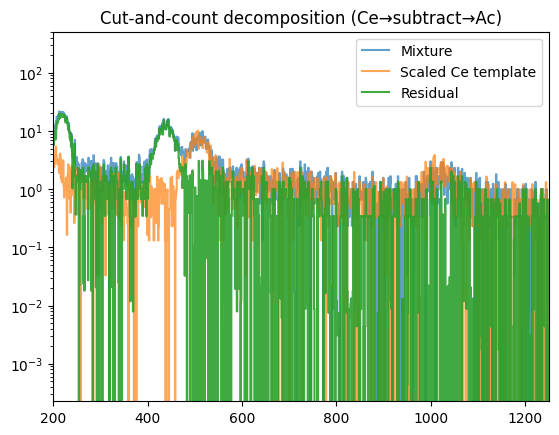

Saved run_id: cutcount_ceac_v2__1ec517b76c


In [17]:
est, extra, fit_arrays = estimate_ceac_mixture_cutcount(
    experiment_id=exp_mix,
    label=mix_label,
    x_keV=x_keV,
    y_mix=y_mix,
    y_ce_template=y_ce_template,
    ce_eff_model=ce_eff_model,
    ac_eff_model=ac_eff_model,
    config=cfg,
    ce_template_label=ce_template_label,
)

print("Estimated activities (Bq):", est.activities_bq)
print("Estimated uncertainties (Bq):", est.uncertainties_bq)
print("Scale Ce template:", extra["scale_ce_template"])

plt.figure()
plt.step(fit_arrays["x_keV"], fit_arrays["y_mix"], where="mid", label="Mixture", alpha=0.7)
plt.step(fit_arrays["x_keV"], fit_arrays["y_ce_scaled"], where="mid", label="Scaled Ce template", alpha=0.7)
plt.step(fit_arrays["x_keV"], fit_arrays["y_residual"], where="mid", label="Residual", alpha=0.9)
plt.yscale("log")
plt.xlim(*cfg.roi_keV)
plt.legend()
plt.title("Cut-and-count decomposition (Ce→subtract→Ac)")
plt.show()

# build a richer run_config (adds provenance) before making run_id
run_config = dict(est.diagnostics.get("run_config", {}))
run_config["templates"] = {
    "ce134": {"experiment_id": exp_ce, "cal_tag": cal_tag, "label": ce_template_label}
}
run_config["eff_models"] = {
    "ce": {"name": ce_eff_model.name, "type": ce_eff_model.model_type},
    "ac": {"name": ac_eff_model.name, "type": ac_eff_model.model_type},
}
# store it back into the estimate for provenance
est.diagnostics["run_config"] = run_config

run_id = ArtifactStore.make_run_id(run_config, prefix=cfg.method_tag)

# Save JSON + arrays (arrays optional; requires the artifacts.py patch)
store.save_cutcount_estimate(
    est,
    run_id=run_id,
    fit_arrays={
        "x_keV": fit_arrays["x_keV"],
        "y_mix": fit_arrays["y_mix"],
        "y_ce_scaled": fit_arrays["y_ce_scaled"],
        "y_residual": fit_arrays["y_residual"],
    },
)

print("Saved run_id:", run_id)

# Visualize

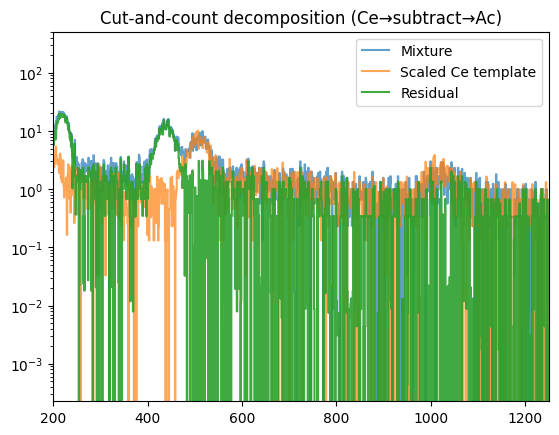

In [12]:
plt.figure()
plt.step(fit_arrays["x_keV"], fit_arrays["y_mix"], where="mid", label="Mixture", alpha=0.7)
plt.step(fit_arrays["x_keV"], fit_arrays["y_ce_scaled"], where="mid", label="Scaled Ce template", alpha=0.7)
plt.step(fit_arrays["x_keV"], fit_arrays["y_residual"], where="mid", label="Residual", alpha=0.9)
plt.yscale("log")
plt.xlim(200, 1250)
plt.legend()
plt.title("Cut-and-count decomposition (Ce→subtract→Ac)")
plt.show()


In [ ]:
fit_arrays = {
    "x_keV": x_keV,
    "y_mix": y_mix,
    "y_template_ce": y_ce_template,
    "y_residual": extra["y_residual"],
    "y_scaled_template_ce": extra["scale_ce"] * y_ce_template,
}

run_id = ArtifactStore.make_run_id(est.diagnostics["run_config"], prefix=cfg.method_tag)
# store.save_cutcount_estimate(est, run_id=run_id)  # + fit_arrays if you add the artifacts patch
store.save_cutcount_estimate(est, run_id=run_id, fit_arrays=fit_arrays)

# Loop

In [ ]:
mix_labels = list(mix_cal.labels)
ce_labels  = list(ce_cal.labels)

for mix_label in mix_labels:
    mix_spec = mix_cal.calibrated[mix_label]
    x_keV = np.asarray(mix_spec["bin_centers_kev"], dtype=float)
    y_mix = np.asarray(mix_spec["counts_vals"], dtype=float)

    for ce_template_label in ce_labels:
        # skip if already saved for this mix label with same run_id
        ce_tpl = ce_cal.calibrated[ce_template_label]
        y_ce_template = np.asarray(ce_tpl["counts_vals"], dtype=float)

        # run
        est, extra, fit_arrays = estimate_ceac_mixture_cutcount(
            experiment_id=exp_mix,
            label=mix_label,
            x_keV=x_keV,
            y_mix=y_mix,
            y_ce_template=y_ce_template,
            ce_eff_model=ce_eff_model,
            ac_eff_model=ac_eff_model,
            config=cfg,
            ce_template_label=ce_template_label,
        )

        run_config = dict(est.diagnostics.get("run_config", {}))
        run_config["templates"] = {
            "ce134": {"experiment_id": exp_ce, "cal_tag": cal_tag, "label": ce_template_label}
        }
        run_config["eff_models"] = {
            "ce": {"name": ce_eff_model.name, "type": ce_eff_model.model_type},
            "ac": {"name": ac_eff_model.name, "type": ac_eff_model.model_type},
        }
        est.diagnostics["run_config"] = run_config

        run_id = ArtifactStore.make_run_id(run_config, prefix=cfg.method_tag)

        # skip if json exists
        existing = set(store.list_cutcount_runs(exp_mix, mix_label))
        if run_id in existing:
            continue

        store.save_cutcount_estimate(
            est,
            run_id=run_id,
            fit_arrays={
                "x_keV": fit_arrays["x_keV"],
                "y_mix": fit_arrays["y_mix"],
                "y_ce_scaled": fit_arrays["y_ce_scaled"],
                "y_residual": fit_arrays["y_residual"],
            },
        )

print("Sweep done.")


# View `runs` table?
- Isn't this meant for `05_persisted.ipynb`?

In [13]:
df_cc = store.cutcount_runs_table(exp_mix)
df_cc.sort_values(["label", "saved_at"]).head(20)

,activity_units,eff_models,experiment_id,label,method_tag,npz_exists,roi_keV,run_id,saved_at,templates
0,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v2,True,"[200.0, 1250.0]",cutcount_ceac_v2__619eb94c8e,2026-02-17T04:39:36.751441+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...


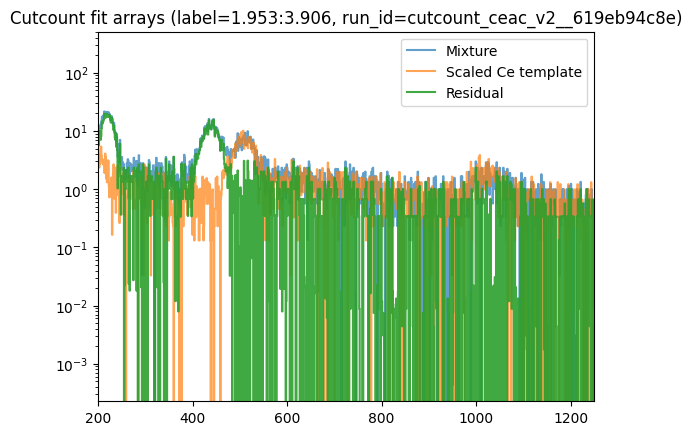

In [14]:
# pick one row
row = df_cc.sort_values("saved_at").iloc[-1]
lab = row["label"]
rid = row["run_id"]

arr = store.load_cutcount_fit_arrays(exp_mix, lab, run_id=rid)

plt.figure()
plt.step(arr["x_keV"], arr["y_mix"], where="mid", label="Mixture", alpha=0.7)
plt.step(arr["x_keV"], arr["y_ce_scaled"], where="mid", label="Scaled Ce template", alpha=0.7)
plt.step(arr["x_keV"], arr["y_residual"], where="mid", label="Residual", alpha=0.9)
plt.yscale("log")
plt.xlim(*cfg.roi_keV)
plt.legend()
plt.title(f"Cutcount fit arrays (label={lab}, run_id={rid})")
plt.show()
